In [29]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [30]:
class AgentState(TypedDict):
    number_1:int
    number_2:int
    operation_1:str
    final_number_1:int

    number_3:int
    number_4:int
    operation_2:str
    final_number_2:int    

In [31]:
def addition_node_1(state:AgentState)->AgentState:
    """this node adds two numbers"""
    state["final_number_1"] = state["number_1"] + state["number_2"]
    return state

def subtraction_node_1(state:AgentState)->AgentState:
    """this node subtracts two numbers"""
    state["final_number_1"] = state["number_1"] - state["number_2"]
    return state

def decide_next_node_1(state:AgentState)->AgentState:
    """this node determines if operation is addition or subtraction"""
    if(state["operation_1"] == "+"):
        return "addition_operation_1"
    elif(state["operation_1"] == "-"):
        return "subtraction_operation_1"

In [32]:
def addition_node_2(state:AgentState)->AgentState:
    """this node adds two numbers"""
    state["final_number_2"] = state["number_3"] + state["number_4"]
    return state

def subtraction_node_2(state:AgentState)->AgentState:
    """this node subtracts two numbers"""
    state["final_number_2"] = state["number_3"] - state["number_4"]
    return state

def decide_next_node_2(state:AgentState)->AgentState:
    """this node determines if operation is addition or subtraction"""
    print(f"OPERATION 2: {state['operation_2']}")
    if(state["operation_2"] == "+"):
        return "addition_operation_2"
    elif(state["operation_2"] == "-"):
        return "subtraction_operation_2"

In [33]:
graph = StateGraph(AgentState)
graph.add_node("addition_node_1",addition_node_1)
graph.add_node("subtraction_node_1",subtraction_node_1)
graph.add_node("router_1",lambda state:state) #the lambda simply states that it is a passthrough, just return the node as-is

graph.add_node("addition_node_2",addition_node_2)
graph.add_node("subtraction_node_2",subtraction_node_2)
graph.add_node("router_2",lambda state:state) #the lambda simply states that it is a passthrough, just return the node as-is

#=========================================

graph.add_edge(START,"router_1")
graph.add_conditional_edges(
    "router_1"
    , decide_next_node_1
    , {"addition_operation_1":"addition_node_1"
        , "subtraction_operation_1":"subtraction_node_1"
    }
)

graph.add_edge("addition_node_1","router_2")
graph.add_edge("subtraction_node_1","router_2")

graph.add_conditional_edges(
    "router_2"
    , decide_next_node_2
    , {"addition_operation_2":"addition_node_2"
        , "subtraction_operation_2":"subtraction_node_2"
    }
)

graph.add_edge("addition_node_2",END)
graph.add_edge("subtraction_node_2",END)

app = graph.compile()


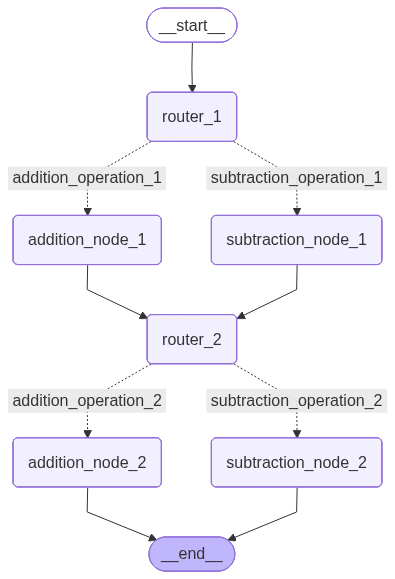

In [34]:
display(Image(app.get_graph().draw_mermaid_png()))

In [35]:
initial_state_1 = AgentState({"number_1":0, "number_2":1, "operation_1":"+", "number_3":0, "number_4":1, "operation_2":"-"})
result = app.invoke(initial_state_1)
print(result)

OPERATION 2: -
{'number_1': 0, 'number_2': 1, 'operation_1': '+', 'final_number_1': 1, 'number_3': 0, 'number_4': 1, 'operation_2': '-', 'final_number_2': -1}
